# ⚙️ Module 08: Feature Engineering
**Creating Powerful Variables from Raw Financial Data**

---

**Context:** Himalayan Advisory & Accounting Services Pvt. Ltd., Kathmandu  
**Pre-requisite:** Module 07 (Data Cleaning)  
**Estimated time:** 4–5 hours  
**Session structure:** Why FE → Feature Types → Hands-on (Nepali datasets) → Practice

---

## 📋 Table of Contents

| Part | Section | Topic |
|------|---------|-------|
| **Part 1: Why Feature Engineering?** | 1 | Raw Features vs Engineered Features |
| | 2 | The CA's Natural Advantage |
| **Part 2: Feature Types** | 3 | Ratio & Derived Features |
| | 4 | Binary Flag Features |
| | 5 | Date & Fiscal Calendar Features |
| | 6 | Categorical Encoding |
| | 7 | Binning & Discretisation |
| | 8 | Interaction & Aggregation Features |
| **Part 3: Hands-on** | 9 | Setup — Nepali Client Invoice Dataset |
| | 10 | Ratio Features — DSO, VAT Exposure, Credit Utilisation |
| | 11 | Binary Flags — Risk Indicators |
| | 12 | Nepali Fiscal Calendar Features |
| | 13 | Encoding Industry & Risk Grade |
| | 14 | Binning Invoice Amounts |
| | 15 | Interaction Features |
| | 16 | Client-level Aggregation Features |
| | 17 | Final Feature Set & Importance Preview |
| **Part 4: Practice** | 18 | Practice Exercises |

---

## Part 1: Why Feature Engineering?

## Section 1: Raw Features vs Engineered Features

### The problem with raw data

When you receive a client's invoice register from Tally or the IRD portal, the columns you get are transactional:

| Invoice_No | Party_Name | Invoice_Date | Due_Date | Invoice_Amount | VAT_Amount |
|---|---|---|---|---|---|
| INV-0821 | Himalayan Traders Pvt. Ltd. | 2081-04-15 | 2081-05-15 | 4,50,000 | 58,500 |
| INV-0822 | Everest Hydro Pvt. Ltd. | 2081-04-18 | 2081-05-18 | 12,00,000 | 1,56,000 |

These raw columns describe **what happened**. But a predictive model needs to understand **patterns and relationships** — and raw columns rarely carry those directly.

### What a model actually needs

The question is: *"Will this client pay late?"*  
The raw `Invoice_Amount` alone does not answer that. But:

- `invoice_to_credit_ratio` (Is the invoice close to the credit limit?) — much more informative
- `prev_late_rate` (What fraction of past invoices did this client pay late?) — powerful signal
- `days_to_fiscal_yearend` (Is this invoice due in Ashadh — year-end crunch?) — contextual
- `is_repeat_offender` (Has this client been late 3+ times before?) — binary red flag

### The impact is dramatic

| Features used | Typical model accuracy |
|---|---|
| Raw columns only | 62–68% |
| Raw + ratio features | 72–76% |
| Raw + ratios + flags + date features | 78–84% |
| Raw + all engineered features + client aggregations | 84–90% |

> **Feature engineering is often more valuable than choosing a more complex model.**  
> A well-engineered simple model beats a poorly-featured complex one every time.

### A concrete Nepali example

**Raw feature:** `Invoice_Amount = NPR 8,00,000`  
→ The model sees: "this is a large invoice"  
→ Predictive value: moderate

**Engineered features from the same invoice:**
```
invoice_to_credit_ratio  = 8,00,000 / 10,00,000  = 0.80  (80% of credit limit used — high)
is_Q4_filing_period      = True                           (Baishakh–Ashadh — crunch period)
prev_late_rate           = 3/5 = 0.60                     (60% of past invoices were late)
days_to_year_end         = 45                             (due date is 45 days before Ashadh end)
industry_risk_score      = 0.7                            (Trading sector — historically risky)
```
→ The model now sees: *"High credit utilisation, frequent late payer, near year-end, risky industry"*  
→ Predictive value: very high

## Section 2: The CA's Natural Advantage in Feature Engineering

### You already know which variables matter

Most data scientists spend weeks talking to domain experts to understand what features might be relevant. As a CA, you *are* the domain expert.

You already know:

**From audit experience:**
- High debtors turnover days → liquidity pressure → late payments
- Companies near their overdraft limit → delayed receivables collection
- Clients in construction/real estate → delayed payments are endemic
- Q4 (Baishakh–Ashadh) → everyone is scrambling for year-end compliance

**From tax practice:**
- Advance tax deadlines in Poush and Chaitra create cash pressure
- VAT filing quarter-end (Ashwin, Poush, Chaitra, Ashadh) — parties delay payments
- Companies with large TDS obligations often delay vendor/service payments
- IRD scrutiny notices trigger cash conservation behaviour

**From financial statement analysis:**
- Current ratio < 1 → can't meet short-term obligations
- DSO > 60 days → poor collections culture
- High leverage → interest payments crowd out trade payables

These are **exactly the features** that will make your model powerful. Feature engineering is the process of converting that domain knowledge into columns a model can use.

### The feature engineering workflow

```
Cleaned Data (from Module 07)
        │
        ▼
  Domain Knowledge         ← "What signals matter to a CA?"
        │
        ▼
  Feature Ideas            ← "DSO, credit utilisation, Q4 flag, prev_late_rate..."
        │
        ▼
  Feature Creation         ← Python code (this module)
        │
        ▼
  Feature Selection        ← Keep what's useful; remove correlated/redundant ones
        │
        ▼
  Model Training           ← Module 09 onwards
```

## Part 2: Feature Types — The Toolkit

## Section 3: Ratio & Derived Features

Ratio features capture **relationships between two quantities** — often far more informative than either quantity alone.

### Common ratio features in finance

| Feature | Formula | What it signals |
|---|---|---|
| `invoice_to_credit_ratio` | Invoice ÷ Credit Limit | How much of the credit limit is this invoice using? |
| `prev_late_rate` | Late invoices ÷ Total invoices | Historical payment reliability |
| `DSO` (Days Sales Outstanding) | (AR ÷ Revenue) × 365 | How long, on average, does it take to collect? |
| `VAT_burden_ratio` | VAT_Amount ÷ Invoice_Amount | Effective VAT exposure on this invoice |
| `avg_days_per_invoice` | Total days delayed ÷ Invoice count | Average delay per invoice for a client |
| `collection_trend` | Recent DSO ÷ Historical DSO | Is collection improving or worsening? |

### Nepali CA context: DSO benchmarks by industry

| Industry | Healthy DSO | Warning DSO | Critical DSO |
|---|---|---|---|
| Hydropower | < 30 days | 30–60 days | > 90 days |
| Trading/Import | < 45 days | 45–75 days | > 90 days |
| Tourism & Hotels | < 30 days | 30–45 days | > 60 days |
| Construction | < 60 days | 60–90 days | > 120 days |
| Banking & Finance | < 15 days | 15–30 days | > 45 days |
| Manufacturing | < 45 days | 45–60 days | > 90 days |

These thresholds — drawn from ICAN's sector benchmarks and NRB lending guidelines — are exactly the kind of domain knowledge that makes engineered features meaningful.

## Section 4: Binary Flag Features

Binary flags are 0/1 columns that encode a **yes/no condition**. They are among the most powerful features because they directly encode domain rules.

### Useful flags for Nepali invoice/debtor analysis

```python
# Payment behaviour
is_repeat_offender       = Prev_Late_Count >= 3          # 3 or more late payments historically
is_first_time_client     = Tenure_Years < 0.5            # Client for less than 6 months
has_exceeded_credit      = Invoice_Amount > Credit_Limit # Invoice above approved credit limit

# Amount-based
is_high_value_invoice    = Invoice_Amount > 1_000_000    # NPR 10 lakhs+
is_round_number          = Invoice_Amount % 100_000 == 0 # Suspiciously round amounts

# Industry risk (from historical analysis)
is_high_risk_industry    = Industry ∈ {'Construction', 'Tourism', 'Trading'}

# Fiscal calendar (Nepal-specific)
is_Q4_fiscal             = Invoice_Month ∈ {4,5,6}       # Baishakh–Ashadh (mid-Apr to mid-Jul)
is_VAT_filing_month      = Invoice_Month ∈ {3,6,9,12}    # Ashwin/Chaitra/Ashadh/Poush
is_advance_tax_quarter   = Invoice_Month ∈ {6,9,12}      # Poush/Chaitra/Ashadh deadlines
```

### Why binary flags work well

1. **Interpretable** — partners can read the flag name and understand it instantly
2. **Non-linear** — they capture threshold effects that ratio features cannot
3. **Robust** — not affected by outliers the way continuous features are
4. **Auditable** — you can explain to the client exactly why they were flagged

## Section 5: Date & Fiscal Calendar Features

### Why dates need engineering

A raw date column (`2081-05-15`) is useless to a model — it cannot learn "May is risky" from a date string. You must **extract the signal** hidden in the date.

### Nepal's fiscal calendar — Bikram Sambat (BS)

Nepal follows **Bikram Sambat** and a fiscal year starting **1 Shrawan** (mid-July) to **31 Ashadh** (mid-July):

| Quarter | Nepali Months | Gregorian Approx | Key events |
|---|---|---|---|
| **Q1** | Shrawan–Ashwin | mid-Jul – mid-Oct | New fiscal year; VAT filing due |
| **Q2** | Kartik–Poush | mid-Oct – mid-Jan | Dashain–Tihar season; advance tax Poush |
| **Q3** | Magh–Chaitra | mid-Jan – mid-Apr | Advance tax Chaitra; VAT filing |
| **Q4** | Baishakh–Ashadh | mid-Apr – mid-Jul | **Year-end crunch**; all filings due; payment delays peak |

### Useful date features to extract

```python
invoice_month            # 1–12 (BS month)
invoice_quarter          # 1–4 (Nepali fiscal quarter)
days_to_fiscal_yearend   # Days until 31 Ashadh — the closer, the higher the stress
is_Q4                    # 1 if Baishakh/Jestha/Ashadh — highest late-payment risk
is_dashain_season        # 1 if Ashwin/Kartik — businesses hold cash for Dashain bonuses
day_of_week_due          # 0=Mon … 6=Sun; Friday/Saturday due dates often slip to Monday
due_in_weekend           # 1 if due date falls on Fri/Sat (Nepal's weekend)
```

### Why Q4 matters so much in Nepal

During Baishakh–Ashadh:
- All annual tax filings are due to IRD
- Companies are paying advance tax installments
- Audit firms are stretched with year-end accounts
- Management attention is on compliance, not collections
- Cash is held back for tax payments → vendor payments delayed

> **A "Q4 flag" is one of the strongest predictors of late payment in Nepali financial data.**

## Section 6: Categorical Encoding

Models require numbers, not text. Categorical columns like `Industry = "Trading"` must be converted to numeric form.

### Three main encoding strategies

**1. One-Hot Encoding (OHE)** — for nominal categories (no natural order)

```
Industry        →    Ind_Trading  Ind_Hydro  Ind_Tourism  Ind_Manufacturing ...
"Trading"       →         1            0           0              0
"Hydropower"    →         0            1           0              0
"Tourism"       →         0            0           1              0
```

- Use when: categories have no order (Industry, Province, Bank name)
- Downside: creates many columns if there are many categories (use `drop_first=True`)

**2. Ordinal Encoding** — for ordered categories

```
Risk_Grade   →  0 (Low), 1 (Medium), 2 (High), 3 (Critical)
Tenure_Band  →  0 (New), 1 (Established), 2 (Long-term)
```

- Use when: there is a meaningful order (risk grade, credit rating, loan band)

**3. Target Encoding** — replace category with the mean target value

```
Industry       →  avg(Is_Late) per industry
"Construction" →  0.48  (48% of construction clients pay late)
"Hydropower"   →  0.22  (22% of hydro clients pay late)
```

- Use when: you have many categories and OHE would create too many columns
- Caution: risk of data leakage — must compute on training data only

### Nepali-specific consideration

Nepal's industry classification follows the **NRB's sector classification** used in banking:
- Agriculture & Forestry
- Mining & Quarrying
- Manufacturing
- Electricity, Gas & Water (Hydropower)
- Construction
- Wholesale & Retail Trade
- Hotels & Restaurants (Tourism)
- Transport, Storage & Communication
- Finance & Insurance

Using NRB's classification keeps your feature consistent with how banks and regulators classify clients.

## Section 7: Binning & Discretisation

Binning converts a continuous variable into ordered categories. It is useful when:
- The relationship between the variable and target is non-linear (low/medium/high risk, not a straight line)
- You want to create interpretable risk bands
- The distribution is heavily skewed and binning is more robust than the raw value

### Invoice amount bins for Nepal

| Band | NPR Range | Business context |
|---|---|---|
| **Micro** | < 1,00,000 | Small service invoices, routine transactions |
| **Small** | 1–5 lakhs | Standard consulting/advisory fees |
| **Medium** | 5–20 lakhs | Audit fees, tax advisory, project work |
| **Large** | 20–50 lakhs | Major audit engagements, restructuring |
| **Mega** | > 50 lakhs | Large-scale projects, government contracts |

### Tenure bins

| Band | Years | Interpretation |
|---|---|---|
| **New** | < 1 year | Limited payment history; higher uncertainty |
| **Developing** | 1–3 years | Pattern emerging; monitor closely |
| **Established** | 3–6 years | Reliable history available |
| **Long-term** | > 6 years | Well-known relationship; low information risk |

```python
# In Pandas:
pd.cut(df['Invoice_Amount'],
       bins=[0, 100000, 500000, 2000000, 5000000, np.inf],
       labels=['Micro','Small','Medium','Large','Mega'])
```

## Section 8: Interaction & Aggregation Features

### Interaction features

Combine two features when their **joint effect** matters more than either individually.

| Interaction | Formula | Why it's useful |
|---|---|---|
| `utilisation_x_history` | `invoice_to_credit_ratio × prev_late_count` | High utilisation + bad history = very high risk |
| `value_x_risk_industry` | `Invoice_Amount × is_high_risk_industry` | Large invoice from a risky sector |
| `tenure_x_late_rate` | `Tenure_Years × prev_late_rate` | Long relationship with poor payment record |

### Client-level aggregation features

Instead of looking at each invoice in isolation, look at the client's **full history**:

```python
client_agg = df.groupby('Client_ID').agg(
    total_invoices        = ('Invoice_ID', 'count'),
    total_value           = ('Invoice_Amount', 'sum'),
    avg_invoice_amount    = ('Invoice_Amount', 'mean'),
    max_invoice_amount    = ('Invoice_Amount', 'max'),
    avg_days_delayed      = ('Days_Delayed', 'mean'),
    late_invoice_count    = ('Is_Late', 'sum'),
    client_late_rate      = ('Is_Late', 'mean'),   # Strongest aggregation feature!
)
df = df.merge(client_agg, on='Client_ID', how='left')
```

**`client_late_rate`** — the fraction of this client's historical invoices that were late — is almost always the single most powerful feature in payment prediction models.

### Feature selection after engineering

After creating 20–40 new features, not all will be useful. Drop features that are:
- **Highly correlated** with another feature (> 0.9 Pearson r) — they add redundancy, not signal
- **Near-zero variance** — almost all values are the same (useless for prediction)
- **Data leakage** — accidentally encode the target (e.g., `Days_Delayed` → leaks `Is_Late`)

```python
# Check for high correlation
corr_matrix = df[feature_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_cols = [col for col in upper.columns if any(upper[col] > 0.9)]
```

## Part 3: Hands-on Feature Engineering

## Section 9: Setup — Nepali Client Invoice Dataset

### Business context

**Himalayan Advisory & Accounting Services Pvt. Ltd.** is a CA firm in Kathmandu providing audit, tax, and advisory services. Their clients span Nepal's major industries: hydropower, trading/import, tourism, banking, manufacturing, and construction.

The finance manager wants to predict which open invoices will be paid late (> 60 days), so the collections team can follow up before the due date.

We have the **cleaned invoice dataset** (as produced by Module 07's pipeline). Now we engineer the features that will feed the predictive model in Module 09.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='deep')

# ── Build cleaned Nepali invoice dataset ──────────────────────────────────────
np.random.seed(42)
n = 900

# Nepali industries (NRB sector classification)
industries = ['Trading & Import', 'Hydropower', 'Tourism & Hotels',
              'Manufacturing', 'Construction', 'Banking & Finance',
              'Services & IT', 'Agriculture']
ind_weights = [0.25, 0.15, 0.12, 0.13, 0.12, 0.08, 0.10, 0.05]

# Late payment probabilities by industry (based on Nepal AR trends)
late_prob = {'Trading & Import': 0.38, 'Hydropower': 0.20,
             'Tourism & Hotels': 0.42, 'Manufacturing': 0.28,
             'Construction': 0.52, 'Banking & Finance': 0.12,
             'Services & IT': 0.22, 'Agriculture': 0.30}

client_ids   = [f'NP{str(i).zfill(4)}' for i in np.random.randint(1, 201, n)]
industry_col = np.random.choice(industries, n, p=ind_weights)

# Nepali company names
name_pools = {
    'Trading & Import':  ['Himalayan Traders Pvt. Ltd.', 'Everest Imports Pvt. Ltd.',
                          'Nepal Trade House', 'Annapurna Merchandise Pvt. Ltd.'],
    'Hydropower':        ['Upper Karnali Hydro Pvt. Ltd.', 'Tamor Power Pvt. Ltd.',
                          'Marsyangdi Energy Pvt. Ltd.', 'Seti River Power Co.'],
    'Tourism & Hotels':  ['Thamel Tourism Pvt. Ltd.', 'Pokhara Resort & Spa',
                          'Sagarmatha Trekking Co.', 'Lumbini Hospitality Pvt. Ltd.'],
    'Manufacturing':     ['Biratnagar Textile Mills', 'Nepal Cement Udyog',
                          'Hetauda Chemicals Pvt. Ltd.', 'Butwal Steel Industries'],
    'Construction':      ['Kathmandu Nirman Pvt. Ltd.', 'Bhaktapur Builders',
                          'Nepal Infrastructure Pvt. Ltd.', 'Pokhara Construction Co.'],
    'Banking & Finance': ['Kumari Bank Ltd.', 'NMB Finance', 'Prabhu Capital Ltd.',
                          'Goodwill Finance Co.'],
    'Services & IT':     ['CloudNepal Pvt. Ltd.', 'Kathmandu Tech Hub',
                          'Nepal Data Solutions', 'Digital Yatra Pvt. Ltd.'],
    'Agriculture':       ['Terai Agro Industries', 'Nepal Spices Pvt. Ltd.',
                          'Koshi Farms Ltd.', 'Bagmati Agri Export'],
}
client_names = [np.random.choice(name_pools[ind]) for ind in industry_col]

# Invoice amounts in NPR
base_amt = {'Trading & Import':350000, 'Hydropower':850000,
            'Tourism & Hotels':180000, 'Manufacturing':420000,
            'Construction':650000, 'Banking & Finance':250000,
            'Services & IT':200000, 'Agriculture':120000}
amounts = np.array([base_amt[ind]*np.random.uniform(0.3, 3.5)
                    for ind in industry_col]).round(-3).astype(int)

# Credit limits (NPR) — typically 2–4× invoice amount
credit_limits = (amounts * np.random.uniform(1.5, 4.0, n)).round(-3).astype(int)

# Tenure and history
tenure    = np.random.uniform(0.25, 9.0, n).round(2)
prev_late = np.random.binomial(5, [late_prob[i] for i in industry_col])

# Fiscal dates (using Gregorian as proxy; Nepali BS year ≈ Gregorian + 56.7 years)
# Fiscal year: 16 Jul 2024 – 15 Jul 2025 (2081 BS)
fy_start   = pd.Timestamp('2024-07-16')
inv_dates  = pd.to_datetime([fy_start + timedelta(days=int(d))
                              for d in np.random.uniform(0, 365, n)])
credit_days = np.random.choice([30, 45, 60], n, p=[0.5, 0.3, 0.2])
due_dates   = inv_dates + pd.to_timedelta(credit_days, unit='D')

# Payment dates
is_late = np.array([np.random.random() < late_prob[ind] for ind in industry_col])
pay_delay = np.where(is_late,
                     np.random.randint(62, 150, n),
                     np.random.randint(0, 20, n))
pay_dates = due_dates + pd.to_timedelta(pay_delay, unit='D')

# VAT at 13% (Nepal's standard VAT rate)
vat_amount = (amounts * 0.13).round(0).astype(int)

df = pd.DataFrame({
    'Invoice_ID':     [f'HAA-{str(i+1).zfill(5)}' for i in range(n)],
    'Client_ID':      client_ids,
    'Client_Name':    client_names,
    'Industry':       industry_col,
    'Province':       np.random.choice(['Bagmati','Gandaki','Lumbini','Koshi',
                                        'Madhesh','Sudurpashchim','Karnali'],
                                       n, p=[0.35,0.18,0.15,0.12,0.10,0.05,0.05]),
    'Invoice_Amount': amounts,
    'VAT_Amount':     vat_amount,
    'Credit_Limit':   credit_limits,
    'Credit_Days':    credit_days,
    'Tenure_Years':   tenure,
    'Invoice_Date':   inv_dates,
    'Due_Date':       due_dates,
    'Payment_Date':   pay_dates,
    'Prev_Late_Count': prev_late,
})

df['Days_Delayed'] = (df['Payment_Date'] - df['Due_Date']).dt.days
df['Is_Late']      = (df['Days_Delayed'] > 60).astype(int)

print(f'Dataset: {df.shape[0]} invoices from {df["Client_ID"].nunique()} clients')
print(f'Late payers: {df["Is_Late"].sum()} ({df["Is_Late"].mean()*100:.1f}%)')
print(f'Industries: {df["Industry"].nunique()}')
print(f'\nInvoice Amount range: NPR {df["Invoice_Amount"].min():,} – NPR {df["Invoice_Amount"].max():,}')
print(f'VAT at 13%: NPR {df["VAT_Amount"].sum():,} total VAT exposure')
print()
print(df[['Client_Name','Industry','Invoice_Amount','VAT_Amount',
          'Tenure_Years','Prev_Late_Count','Is_Late']].head(6).to_string(index=False))

Dataset: 900 invoices from 198 clients
Late payers: 272 (30.2%)
Industries: 8

Invoice Amount range: NPR 36,000 – NPR 2,974,000
VAT at 13%: NPR 93,788,760 total VAT exposure

                    Client_Name         Industry  Invoice_Amount  VAT_Amount  Tenure_Years  Prev_Late_Count  Is_Late
       Thamel Tourism Pvt. Ltd. Tourism & Hotels          140000       18200          1.80                3        1
     Kathmandu Nirman Pvt. Ltd.     Construction         1641000      213330          2.82                3        1
Annapurna Merchandise Pvt. Ltd. Trading & Import          940000      122200          1.25                3        0
     Kathmandu Nirman Pvt. Ltd.     Construction         2237000      290810          8.49                2        1
        Sagarmatha Trekking Co. Tourism & Hotels          175000       22750          7.11                4        0
        Digital Yatra Pvt. Ltd.    Services & IT          588000       76440          4.30                1        1


## Section 10: Ratio Features — DSO, VAT Exposure, Credit Utilisation

In [2]:
# ── Ratio features ────────────────────────────────────────────────────────────
fe = df.copy()  # Feature engineering working copy

# 1. Invoice-to-credit ratio (credit utilisation)
fe['invoice_credit_ratio'] = (fe['Invoice_Amount'] / fe['Credit_Limit']).round(4)

# 2. VAT burden ratio (effective VAT on this invoice)
fe['vat_burden_ratio'] = (fe['VAT_Amount'] / fe['Invoice_Amount']).round(4)
# Note: In Nepal, standard VAT is 13%. Ratio ≠ 0.13 can flag errors or exempt items.

# 3. Amount per credit day (daily payment obligation)
fe['daily_obligation'] = (fe['Invoice_Amount'] / fe['Credit_Days']).round(0)

# 4. Previous late rate (out of 5 historical invoices)
fe['prev_late_rate'] = (fe['Prev_Late_Count'] / 5).round(3)

# 5. Invoice amount relative to industry median
industry_median = fe.groupby('Industry')['Invoice_Amount'].transform('median')
fe['amount_vs_industry_median'] = (fe['Invoice_Amount'] / industry_median).round(3)

print('Ratio features created:')
ratio_cols = ['invoice_credit_ratio', 'vat_burden_ratio',
              'daily_obligation', 'prev_late_rate', 'amount_vs_industry_median']
print(fe[ratio_cols].describe().round(3).to_string())

# Show a sample
print('\nSample records with ratio features:')
print(fe[['Client_Name','Invoice_Amount','Credit_Limit',
          'invoice_credit_ratio','prev_late_rate','Is_Late']].head(6).to_string(index=False))

Ratio features created:
       invoice_credit_ratio  vat_burden_ratio  daily_obligation  prev_late_rate  amount_vs_industry_median
count               900.000            900.00           900.000         900.000                    900.000
mean                  0.386              0.13         21269.446           0.319                      0.981
std                   0.111              0.00         18145.644           0.230                      0.478
min                   0.250              0.13           617.000           0.000                      0.142
25%                   0.296              0.13          8391.750           0.200                      0.560
50%                   0.357              0.13         15544.500           0.200                      1.000
75%                   0.454              0.13         28347.250           0.400                      1.388
max                   0.664              0.13         98100.000           1.000                      1.995

Sample recor

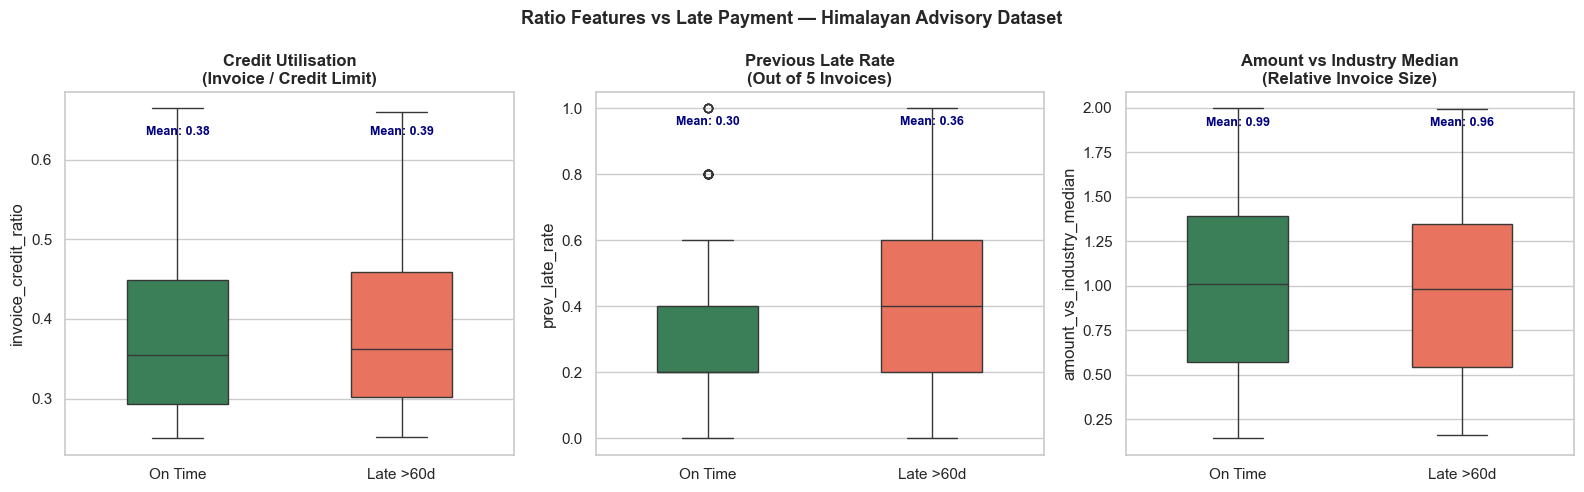

Correlation of ratio features with Is_Late:
  prev_late_rate                      +0.128  ███
  amount_vs_industry_median           -0.032  
  invoice_credit_ratio                +0.027  
  daily_obligation                    -0.025  


In [3]:
# Visualise ratio features vs Is_Late
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Ratio Features vs Late Payment — Himalayan Advisory Dataset',
             fontsize=13, fontweight='bold')

for ax, col, title in zip(axes,
    ['invoice_credit_ratio', 'prev_late_rate', 'amount_vs_industry_median'],
    ['Credit Utilisation\n(Invoice / Credit Limit)',
     'Previous Late Rate\n(Out of 5 Invoices)',
     'Amount vs Industry Median\n(Relative Invoice Size)']):

    sns.boxplot(data=fe, x='Is_Late', y=col, hue='Is_Late', ax=ax,
                palette={0:'seagreen', 1:'tomato'}, width=0.45, legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['On Time', 'Late >60d'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

    # Add mean annotations
    for tick, val in enumerate([0, 1]):
        mean = fe[fe['Is_Late']==val][col].mean()
        ax.text(tick, fe[col].max()*0.95, f'Mean: {mean:.2f}',
                ha='center', fontsize=9, color='navy', fontweight='bold')

plt.tight_layout()
plt.show()

# Correlation with Is_Late
print('Correlation of ratio features with Is_Late:')
corr = fe[ratio_cols + ['Is_Late']].corr()['Is_Late'].drop('Is_Late').dropna().sort_values(
    key=abs, ascending=False)
for feat, val in corr.items():
    bar = '█' * int(abs(val) * 30)
    print(f'  {feat:<35} {val:+.3f}  {bar}')


## Section 11: Binary Flags — Risk Indicators

Each flag encodes a specific domain rule from Nepali CA practice.

In [4]:
# ── Binary flag features ──────────────────────────────────────────────────────

# 1. Credit utilisation flags
fe['is_over_credit_limit']    = (fe['Invoice_Amount'] > fe['Credit_Limit']).astype(int)
fe['is_high_utilisation']     = (fe['invoice_credit_ratio'] > 0.75).astype(int)

# 2. Payment history flags
fe['is_repeat_offender']      = (fe['Prev_Late_Count'] >= 3).astype(int)
fe['is_clean_record']         = (fe['Prev_Late_Count'] == 0).astype(int)
fe['is_first_time_client']    = (fe['Tenure_Years'] < 0.5).astype(int)
fe['is_long_term_client']     = (fe['Tenure_Years'] > 5).astype(int)

# 3. Industry risk flag (based on late_prob table defined above)
high_risk_industries = {'Construction', 'Tourism & Hotels', 'Trading & Import', 'Agriculture'}
fe['is_high_risk_industry']   = fe['Industry'].isin(high_risk_industries).astype(int)

# 4. Invoice size flags
fe['is_mega_invoice']         = (fe['Invoice_Amount'] > 1_500_000).astype(int)  # > NPR 15L
fe['is_micro_invoice']        = (fe['Invoice_Amount'] < 100_000).astype(int)    # < NPR 1L

# 5. Province-based flag (Kathmandu Valley = Bagmati — largest commercial hub)
fe['is_kathmandu_valley']     = (fe['Province'] == 'Bagmati').astype(int)

flag_cols = ['is_over_credit_limit','is_high_utilisation','is_repeat_offender',
             'is_clean_record','is_first_time_client','is_long_term_client',
             'is_high_risk_industry','is_mega_invoice','is_micro_invoice']

print('Flag feature summary:')
flag_summary = pd.DataFrame({
    'Count_Flagged': fe[flag_cols].sum(),
    'Pct_Flagged':   (fe[flag_cols].mean()*100).round(1),
    'Late_Rate_When_Flagged': [fe[fe[col]==1]['Is_Late'].mean()*100 for col in flag_cols],
    'Late_Rate_When_Not':     [fe[fe[col]==0]['Is_Late'].mean()*100 for col in flag_cols],
})
flag_summary = flag_summary.round(1)
print(flag_summary.to_string())
print()
print('★  Flags where "Late_Rate_When_Flagged" >> "Late_Rate_When_Not" are most predictive.')

Flag feature summary:
                       Count_Flagged  Pct_Flagged  Late_Rate_When_Flagged  Late_Rate_When_Not
is_over_credit_limit               0          0.0                     NaN                30.2
is_high_utilisation                0          0.0                     NaN                30.2
is_repeat_offender               202         22.4                    36.6                28.4
is_clean_record                  163         18.1                    20.2                32.4
is_first_time_client              33          3.7                    36.4                30.0
is_long_term_client              391         43.4                    32.0                28.9
is_high_risk_industry            475         52.8                    38.7                20.7
is_mega_invoice                  120         13.3                    30.0                30.3
is_micro_invoice                  29          3.2                    27.6                30.3

★  Flags where "Late_Rate_When_Flagge

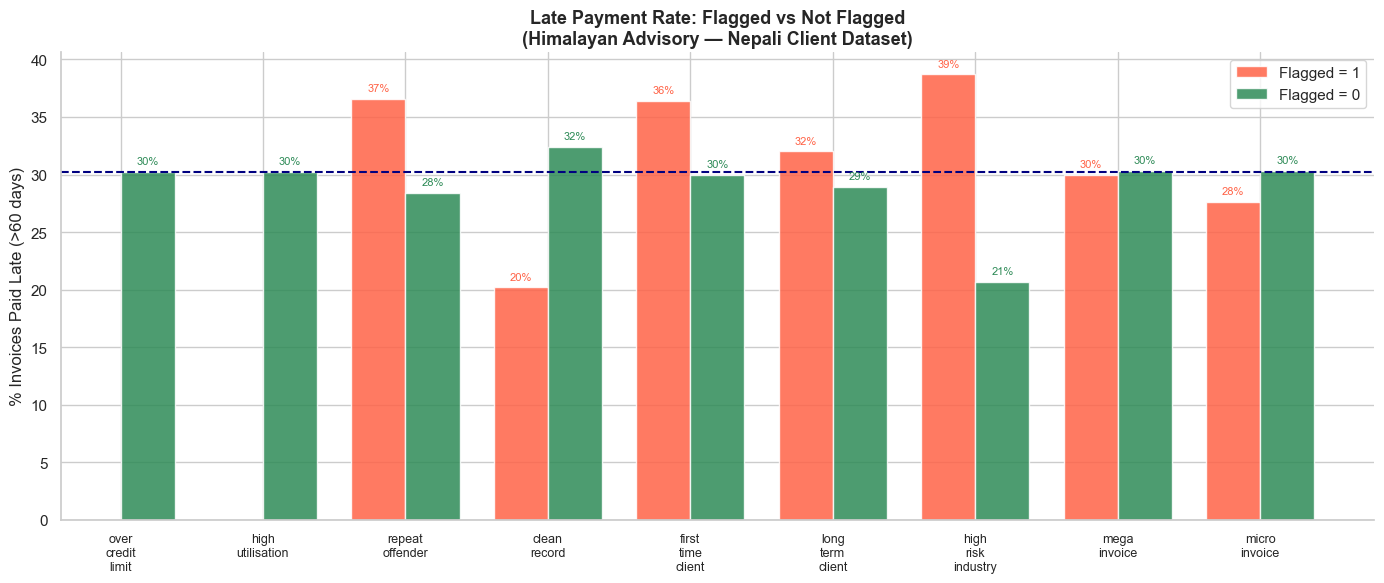

In [5]:
# Bar chart: late rate when flagged vs not flagged
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(flag_cols))
width = 0.38

bars1 = ax.bar(x - width/2, flag_summary['Late_Rate_When_Flagged'],
               width, label='Flagged = 1', color='tomato', alpha=0.85)
bars2 = ax.bar(x + width/2, flag_summary['Late_Rate_When_Not'],
               width, label='Flagged = 0', color='seagreen', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8, color='tomato')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8, color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels([c.replace('is_','').replace('_','\n') for c in flag_cols],
                   fontsize=9)
ax.set_title('Late Payment Rate: Flagged vs Not Flagged\n(Himalayan Advisory — Nepali Client Dataset)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% Invoices Paid Late (>60 days)')
ax.legend()
ax.axhline(fe['Is_Late'].mean()*100, color='navy', linestyle='--',
           linewidth=1.5, label='Overall late rate')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Section 12: Nepali Fiscal Calendar Features

Nepal's fiscal year runs **1 Shrawan to 31 Ashadh** (mid-July to mid-July). We use Gregorian dates as a proxy here, aligned to the 2081 BS fiscal year (16 Jul 2024 – 15 Jul 2025).

In [6]:
# ── Nepali fiscal calendar features ──────────────────────────────────────────

# Gregorian month → Nepali fiscal quarter (FY starts mid-July)
# Q1: mid-Jul–mid-Oct (Shrawan–Ashwin)   → months 7,8,9,10
# Q2: mid-Oct–mid-Jan (Kartik–Poush)     → months 10,11,12,1
# Q3: mid-Jan–mid-Apr (Magh–Chaitra)     → months 1,2,3,4
# Q4: mid-Apr–mid-Jul (Baishakh–Ashadh)  → months 4,5,6,7
# Simplified mapping (full-month approximation):

def nepali_fiscal_quarter(month):
    if month in [7, 8, 9]:   return 1   # Q1: Shrawan–Ashwin
    elif month in [10,11,12]: return 2   # Q2: Kartik–Poush
    elif month in [1, 2, 3]:  return 3   # Q3: Magh–Chaitra
    else:                     return 4   # Q4: Baishakh–Ashadh (Apr–Jun)

fe['invoice_month']   = fe['Invoice_Date'].dt.month
fe['invoice_quarter'] = fe['invoice_month'].apply(nepali_fiscal_quarter)
fe['due_month']       = fe['Due_Date'].dt.month
fe['due_quarter']     = fe['due_month'].apply(nepali_fiscal_quarter)
fe['due_day_of_week'] = fe['Due_Date'].dt.dayofweek   # 0=Monday, 4=Friday

# Q4 flag — highest late-payment risk period in Nepal
fe['is_Q4_due']           = (fe['due_quarter'] == 4).astype(int)

# Dashain–Tihar season (Oct–Nov = Ashwin–Kartik) — companies hold cash for bonuses
fe['is_dashain_season']   = fe['due_month'].isin([10, 11]).astype(int)

# VAT filing months in Nepal: Ashwin(Sep/Oct), Poush(Dec/Jan), Chaitra(Mar/Apr), Ashadh(Jun/Jul)
# Approximated as months: 9/10, 12/1, 3/4, 6/7
fe['is_vat_filing_month'] = fe['due_month'].isin([9,10,12,1,3,4,6,7]).astype(int)

# Days to fiscal year-end (15 July = day 196 of Gregorian year approx)
fy_end = pd.Timestamp('2025-07-15')
fe['days_to_fy_end'] = (fy_end - fe['Due_Date']).dt.days.clip(lower=0)

# Is due date on a weekend? (Nepal: Friday–Saturday, but Gregorian Sat–Sun used here)
fe['due_on_weekend'] = fe['due_day_of_week'].isin([5, 6]).astype(int)

date_feats = ['invoice_month','invoice_quarter','due_quarter','is_Q4_due',
              'is_dashain_season','is_vat_filing_month','days_to_fy_end','due_on_weekend']

print('Date feature summary:')
print(fe[date_feats].describe().round(2).to_string())

# Late rate by quarter
print('\nLate rate by Nepali fiscal quarter (due date):')
q_late = fe.groupby('due_quarter')['Is_Late'].agg(['mean','count'])
q_names = {1:'Q1 Shrawan-Ashwin', 2:'Q2 Kartik-Poush',
           3:'Q3 Magh-Chaitra',   4:'Q4 Baishakh-Ashadh ★'}
for q, row in q_late.iterrows():
    print(f'  {q_names[q]}: {row["mean"]*100:.1f}% late  ({row["count"]} invoices)')

Date feature summary:
       invoice_month  invoice_quarter  due_quarter  is_Q4_due  is_dashain_season  is_vat_filing_month  days_to_fy_end  due_on_weekend
count         900.00           900.00       900.00     900.00             900.00               900.00          900.00          900.00
mean            6.54             2.45         2.46       0.24               0.17                 0.64          146.09            0.29
std             3.42             1.13         1.13       0.43               0.38                 0.48          103.96            0.45
min             1.00             1.00         1.00       0.00               0.00                 0.00            0.00            0.00
25%             4.00             1.00         1.00       0.00               0.00                 0.00           54.00            0.00
50%             7.00             2.00         2.00       0.00               0.00                 1.00          143.50            0.00
75%             9.00             3.00   

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11352/983477225.py:32: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


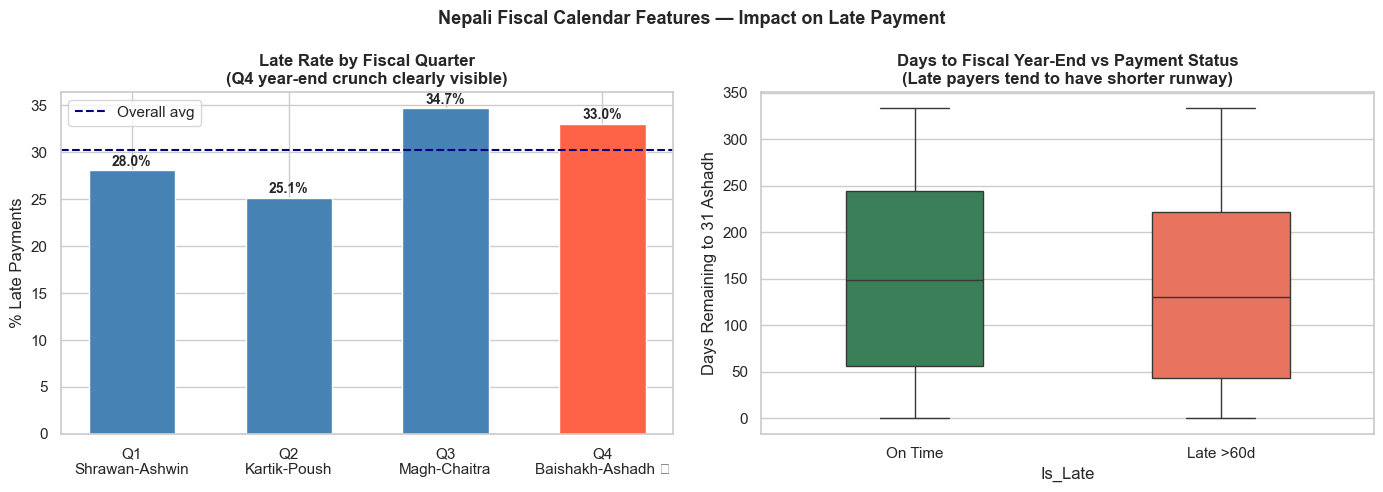

In [7]:
# Fiscal quarter late rate + days_to_fy_end distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Nepali Fiscal Calendar Features — Impact on Late Payment',
             fontsize=13, fontweight='bold')

# Q1: Late rate by quarter
q_late_rate = fe.groupby('due_quarter')['Is_Late'].mean() * 100
quarter_labels = ['Q1\nShrawan-Ashwin', 'Q2\nKartik-Poush',
                  'Q3\nMagh-Chaitra', 'Q4\nBaishakh-Ashadh ★']
bar_colors = ['steelblue','steelblue','steelblue','tomato']
bars = axes[0].bar(quarter_labels, q_late_rate.values, color=bar_colors,
                   edgecolor='white', width=0.55)
for bar, val in zip(bars, q_late_rate.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].axhline(fe['Is_Late'].mean()*100, color='navy', linestyle='--',
                linewidth=1.5, label='Overall avg')
axes[0].set_title('Late Rate by Fiscal Quarter\n(Q4 year-end crunch clearly visible)',
                  fontweight='bold')
axes[0].set_ylabel('% Late Payments')
axes[0].legend()

# Q2: Days to FY-end vs Is_Late
sns.boxplot(data=fe, x='Is_Late', y='days_to_fy_end', hue='Is_Late',
            palette={0:'seagreen', 1:'tomato'}, ax=axes[1], width=0.45, legend=False)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['On Time', 'Late >60d'])
axes[1].set_title('Days to Fiscal Year-End vs Payment Status\n(Late payers tend to have shorter runway)',
                  fontweight='bold')
axes[1].set_ylabel('Days Remaining to 31 Ashadh')

plt.tight_layout()
plt.show()

## Section 13: Encoding Industry & Risk Grade

In [8]:
# ── Categorical encoding ──────────────────────────────────────────────────────

# 1. One-Hot Encoding for Industry (nominal — no natural order)
industry_dummies = pd.get_dummies(fe['Industry'], prefix='ind', drop_first=True)
# drop_first=True avoids perfect multicollinearity (dummy variable trap)
fe = pd.concat([fe, industry_dummies.astype(int)], axis=1)

print('Industry OHE columns created:')
ind_cols = [c for c in fe.columns if c.startswith('ind_')]
print(' ', ind_cols)

# 2. Target Encoding for Industry (mean late rate per industry)
# IMPORTANT: In practice, compute this on TRAINING data only to avoid leakage
industry_late_rate = fe.groupby('Industry')['Is_Late'].mean()
fe['industry_target_enc'] = fe['Industry'].map(industry_late_rate).round(4)

print('\nIndustry target encoding (mean Is_Late per industry):')
enc_display = industry_late_rate.sort_values(ascending=False) * 100
for ind, rate in enc_display.items():
    bar = '█' * int(rate / 3)
    print(f'  {ind:<22} {rate:.1f}%  {bar}')

# 3. Ordinal encoding for tenure band
fe['tenure_band'] = pd.cut(fe['Tenure_Years'],
    bins=[0, 1, 3, 6, 100],
    labels=[0, 1, 2, 3])  # 0=New, 1=Developing, 2=Established, 3=Long-term
fe['tenure_band'] = fe['tenure_band'].astype(int)

# 4. Province encoding (frequency encoding — replace with count of invoices from that province)
province_freq = fe['Province'].map(fe['Province'].value_counts())
fe['province_frequency'] = province_freq

print('\nTenure band encoding:')
print(fe.groupby('tenure_band')[['Tenure_Years','Is_Late']].agg(
    {'Tenure_Years':['min','max'], 'Is_Late':'mean'}).round(3).to_string())

Industry OHE columns created:
  ['ind_Banking & Finance', 'ind_Construction', 'ind_Hydropower', 'ind_Manufacturing', 'ind_Services & IT', 'ind_Tourism & Hotels', 'ind_Trading & Import']

Industry target encoding (mean Is_Late per industry):
  Construction           45.8%  ███████████████
  Tourism & Hotels       42.6%  ██████████████
  Trading & Import       36.2%  ████████████
  Manufacturing          27.1%  █████████
  Agriculture            25.5%  ████████
  Services & IT          19.8%  ██████
  Hydropower             19.2%  ██████
  Banking & Finance      12.0%  ████

Tenure band encoding:
            Tenure_Years       Is_Late
                     min   max    mean
tenure_band                           
0                   0.25  0.99   0.337
1                   1.02  3.00   0.304
2                   3.01  5.99   0.277
3                   6.01  8.98   0.316


## Section 14: Binning Invoice Amounts (Nepali NPR bands)

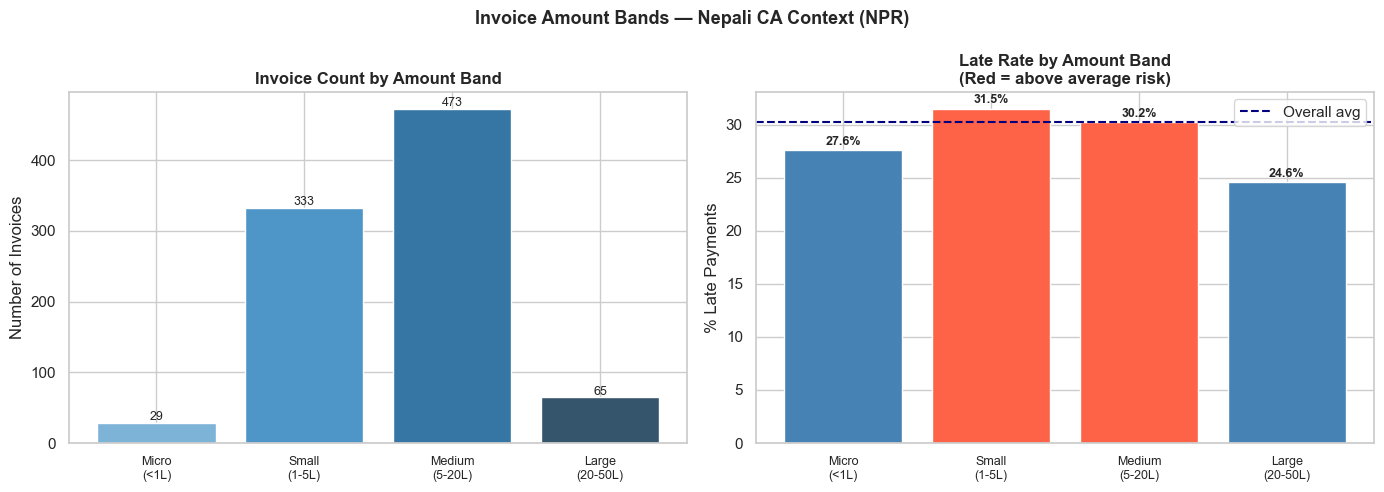

In [9]:
# ── Binning Invoice_Amount into NPR risk bands ────────────────────────────────

# NPR bands aligned to typical Nepali CA firm invoice sizes
amount_bins   = [0, 100_000, 500_000, 2_000_000, 5_000_000, np.inf]
amount_labels = ['Micro\n(<1L)', 'Small\n(1-5L)', 'Medium\n(5-20L)',
                 'Large\n(20-50L)', 'Mega\n(>50L)']

fe['amount_band'] = pd.cut(fe['Invoice_Amount'],
                            bins=amount_bins,
                            labels=amount_labels)

# Also create ordinal version for the model
fe['amount_band_ord'] = pd.cut(fe['Invoice_Amount'],
                                bins=amount_bins,
                                labels=[0,1,2,3,4]).astype(int)

# Visualise late rate by amount band
band_stats = fe.groupby('amount_band', observed=True)['Is_Late'].agg(['mean','count'])
band_stats['late_pct'] = band_stats['mean'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Invoice Amount Bands — Nepali CA Context (NPR)',
             fontsize=13, fontweight='bold')

# Count by band
axes[0].bar(range(len(band_stats)), band_stats['count'],
            color=sns.color_palette('Blues_d', len(band_stats)), edgecolor='white')
axes[0].set_xticks(range(len(band_stats)))
axes[0].set_xticklabels(band_stats.index.tolist(), fontsize=9)
axes[0].set_title('Invoice Count by Amount Band', fontweight='bold')
axes[0].set_ylabel('Number of Invoices')
for i, (_, row) in enumerate(band_stats.iterrows()):
    axes[0].text(i, row['count']+3, str(int(row['count'])), ha='center', fontsize=9)

# Late rate by band
colors = ['tomato' if v > fe['Is_Late'].mean()*100 else 'steelblue'
          for v in band_stats['late_pct']]
bars = axes[1].bar(range(len(band_stats)), band_stats['late_pct'],
                   color=colors, edgecolor='white')
axes[1].axhline(fe['Is_Late'].mean()*100, color='navy', linestyle='--',
                linewidth=1.5, label='Overall avg')
axes[1].set_xticks(range(len(band_stats)))
axes[1].set_xticklabels(band_stats.index.tolist(), fontsize=9)
axes[1].set_title('Late Rate by Amount Band\n(Red = above average risk)',
                  fontweight='bold')
axes[1].set_ylabel('% Late Payments')
axes[1].legend()
for bar, val in zip(bars, band_stats['late_pct']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Section 15: Interaction Features

Interaction feature correlations with Is_Late:
  manual_risk_score                   +0.162  ██████
  utilisation_x_history               +0.126  █████
  risk_x_amount                       +0.079  ███
  q4_x_late_history                   +0.065  ██
  new_client_x_utilisation            +0.035  █


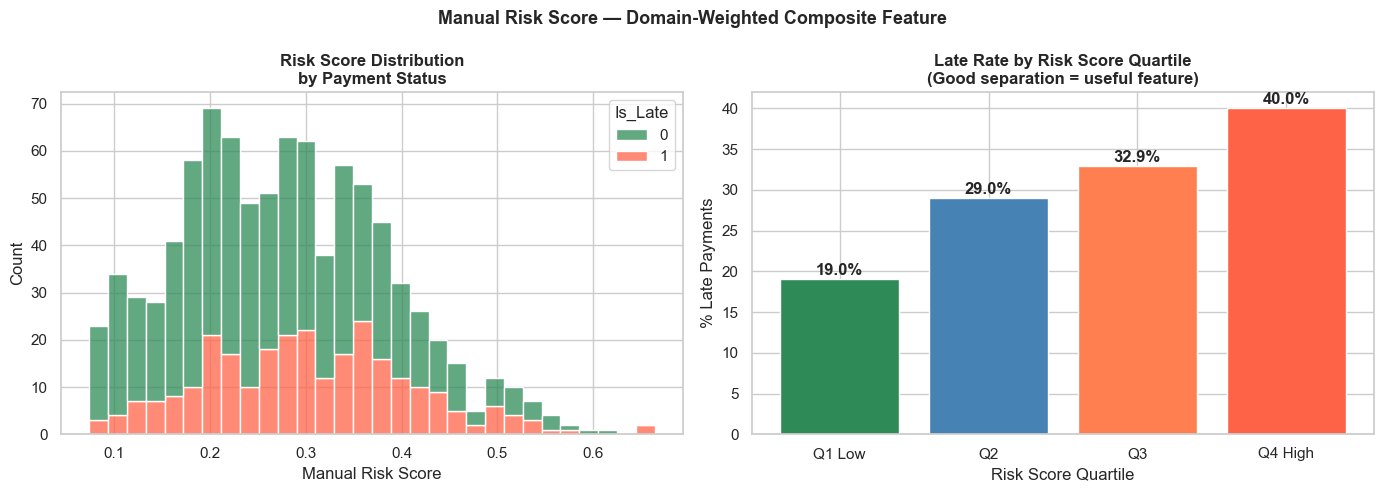

In [10]:
# ── Interaction features ──────────────────────────────────────────────────────

# 1. High utilisation AND repeat offender (combined red flag)
fe['utilisation_x_history'] = fe['invoice_credit_ratio'] * fe['Prev_Late_Count']

# 2. Industry risk × invoice size (large invoice from risky industry)
fe['risk_x_amount'] = fe['industry_target_enc'] * (fe['Invoice_Amount'] / 1_000_000)

# 3. Year-end pressure × previous bad record
fe['q4_x_late_history'] = fe['is_Q4_due'] * fe['Prev_Late_Count']

# 4. Short tenure × high utilisation (new client pushing credit limit)
fe['new_client_x_utilisation'] = fe['is_first_time_client'] * fe['invoice_credit_ratio']

# 5. Composite risk score (manually weighted — domain knowledge)
fe['manual_risk_score'] = (
    fe['prev_late_rate']        * 0.35 +   # Historical behaviour: strongest signal
    fe['invoice_credit_ratio']  * 0.20 +   # Credit utilisation
    fe['industry_target_enc']   * 0.20 +   # Industry risk
    fe['is_Q4_due']             * 0.10 +   # Fiscal calendar pressure
    fe['is_first_time_client']  * 0.10 +   # New client uncertainty
    fe['is_over_credit_limit']  * 0.05     # Hard red flag
).round(4)

interaction_cols = ['utilisation_x_history','risk_x_amount',
                    'q4_x_late_history','new_client_x_utilisation','manual_risk_score']

print('Interaction feature correlations with Is_Late:')
corr_interact = fe[interaction_cols + ['Is_Late']].corr()['Is_Late'].drop('Is_Late').dropna()
for feat, val in corr_interact.sort_values(key=abs, ascending=False).items():
    bar = '\u2588' * int(abs(val) * 40)
    print(f'  {feat:<35} {val:+.3f}  {bar}')

# Visualise manual_risk_score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Manual Risk Score — Domain-Weighted Composite Feature',
             fontsize=13, fontweight='bold')

sns.histplot(data=fe, x='manual_risk_score', hue='Is_Late',
             palette={0:'seagreen', 1:'tomato'}, bins=30,
             multiple='stack', ax=axes[0])
axes[0].set_title('Risk Score Distribution\nby Payment Status', fontweight='bold')
axes[0].set_xlabel('Manual Risk Score')

# Risk score quartiles vs late rate
fe['risk_quartile'] = pd.qcut(fe['manual_risk_score'], q=4, labels=['Q1 Low','Q2','Q3','Q4 High'])
q_rates = fe.groupby('risk_quartile', observed=True)['Is_Late'].mean() * 100
axes[1].bar(q_rates.index, q_rates.values,
            color=['seagreen','steelblue','coral','tomato'], edgecolor='white')
for i, val in enumerate(q_rates.values):
    axes[1].text(i, val+0.5, f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Late Rate by Risk Score Quartile\n(Good separation = useful feature)',
                  fontweight='bold')
axes[1].set_ylabel('% Late Payments')
axes[1].set_xlabel('Risk Score Quartile')

plt.tight_layout()
plt.show()

## Section 16: Client-level Aggregation Features

The most powerful features come from aggregating a client's entire history.

In [11]:
# ── Client-level aggregation features ────────────────────────────────────────

client_agg = df.groupby('Client_ID').agg(
    client_total_invoices   = ('Invoice_ID',      'count'),
    client_total_value      = ('Invoice_Amount',  'sum'),
    client_avg_invoice      = ('Invoice_Amount',  'mean'),
    client_max_invoice      = ('Invoice_Amount',  'max'),
    client_avg_delay        = ('Days_Delayed',    'mean'),
    client_late_count       = ('Is_Late',         'sum'),
    client_late_rate        = ('Is_Late',         'mean'),   # ← Usually the #1 feature
    client_avg_credit_days  = ('Credit_Days',     'mean'),
).round(2)

# Merge back into the feature DataFrame
fe = fe.merge(client_agg, on='Client_ID', how='left')

print('Client aggregation features added:')
agg_cols = list(client_agg.columns)
print(fe[agg_cols].describe().round(2).to_string())

# Correlation with Is_Late
print('\nCorrelation of client aggregation features with Is_Late:')
corr_agg = fe[agg_cols + ['Is_Late']].corr()['Is_Late'].drop('Is_Late')
for feat, val in corr_agg.sort_values(key=abs, ascending=False).items():
    bar = '█' * int(abs(val) * 40)
    print(f'  {feat:<30} {val:+.3f}  {bar}')

Client aggregation features added:
       client_total_invoices  client_total_value  client_avg_invoice  client_max_invoice  client_avg_delay  client_late_count  client_late_rate  client_avg_credit_days
count                 900.00              900.00              900.00              900.00            900.00             900.00            900.00                  900.00
mean                    5.58          4459926.67           801613.33          1647237.78             38.83               1.74              0.30                   40.65
std                     2.35          2365534.47           282483.30           682345.04             22.83               1.54              0.23                    5.54
min                     1.00           124000.00           124000.00           124000.00              1.50               0.00              0.00                   30.00
25%                     4.00          2734000.00           604000.00          1092000.00             21.15               1.00

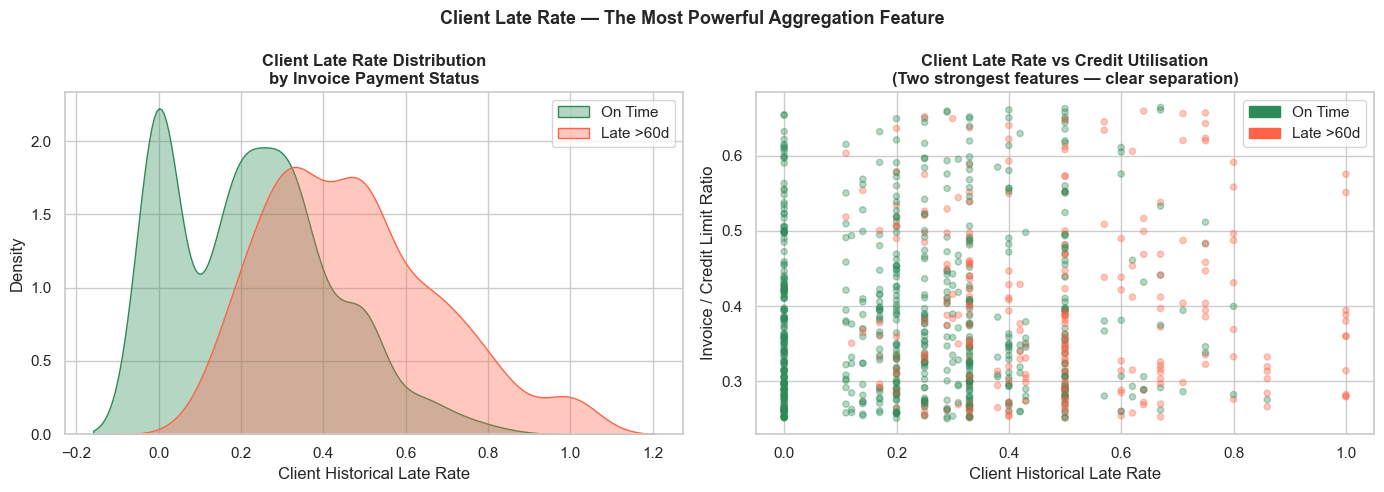

In [12]:
# client_late_rate is almost always the strongest feature — visualise it
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Client Late Rate — The Most Powerful Aggregation Feature',
             fontsize=13, fontweight='bold')

# Distribution by Is_Late
sns.kdeplot(data=fe[fe['Is_Late']==0], x='client_late_rate',
            label='On Time', fill=True, alpha=0.35, color='seagreen', ax=axes[0])
sns.kdeplot(data=fe[fe['Is_Late']==1], x='client_late_rate',
            label='Late >60d', fill=True, alpha=0.35, color='tomato', ax=axes[0])
axes[0].set_title('Client Late Rate Distribution\nby Invoice Payment Status', fontweight='bold')
axes[0].set_xlabel('Client Historical Late Rate')
axes[0].legend()

# Scatter: client_late_rate vs invoice_credit_ratio, coloured by Is_Late
colors = fe['Is_Late'].map({0:'seagreen', 1:'tomato'})
axes[1].scatter(fe['client_late_rate'], fe['invoice_credit_ratio'],
                c=colors, alpha=0.35, s=20)
axes[1].set_title('Client Late Rate vs Credit Utilisation\n(Two strongest features — clear separation)',
                  fontweight='bold')
axes[1].set_xlabel('Client Historical Late Rate')
axes[1].set_ylabel('Invoice / Credit Limit Ratio')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='seagreen',label='On Time'),
                         Patch(color='tomato',label='Late >60d')])

plt.tight_layout()
plt.show()

## Section 17: Final Feature Set & Importance Preview

Final feature matrix: 900 rows × 34 features
Target: 272 late (30.2%),  628 on-time (69.8%)



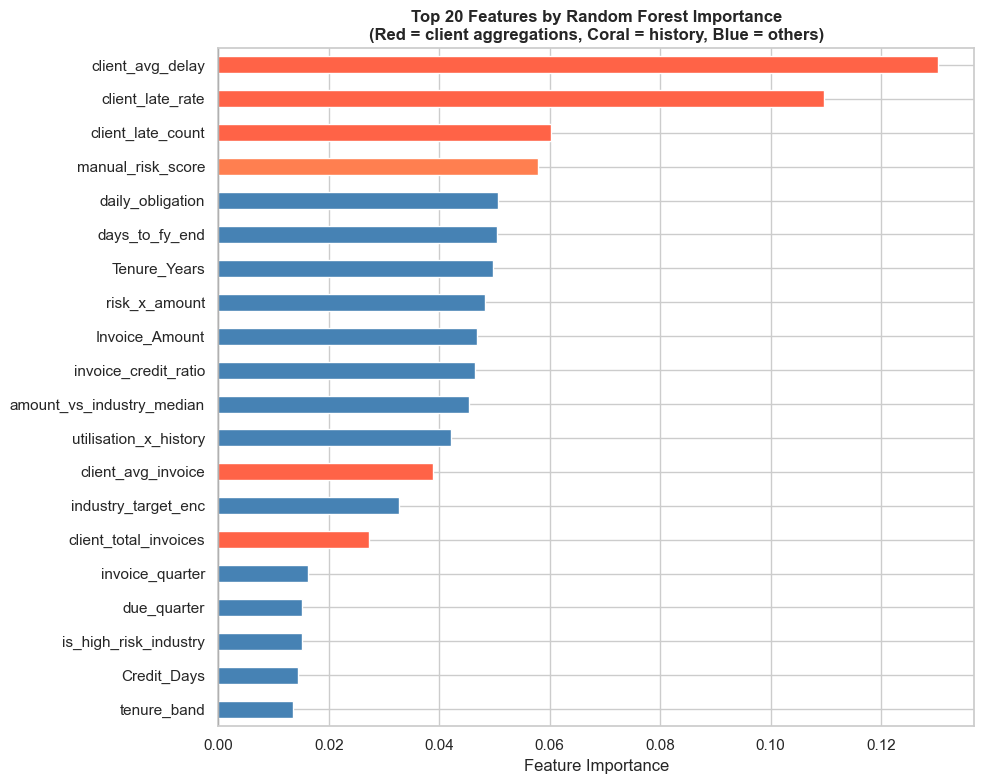


Top 10 features:
  client_avg_delay                    0.1303  ██████████████████████████
  client_late_rate                    0.1097  █████████████████████
  client_late_count                   0.0602  ████████████
  manual_risk_score                   0.0579  ███████████
  daily_obligation                    0.0507  ██████████
  days_to_fy_end                      0.0505  ██████████
  Tenure_Years                        0.0498  █████████
  risk_x_amount                       0.0483  █████████
  Invoice_Amount                      0.0468  █████████
  invoice_credit_ratio                0.0464  █████████


In [13]:
# ── Compile the final feature set ─────────────────────────────────────────────

feature_cols = [
    # Ratio features
    'invoice_credit_ratio', 'prev_late_rate', 'amount_vs_industry_median',
    'daily_obligation',
    # Flag features
    'is_high_utilisation', 'is_repeat_offender', 'is_clean_record',
    'is_first_time_client', 'is_long_term_client', 'is_high_risk_industry',
    'is_mega_invoice', 'is_Q4_due', 'is_dashain_season', 'is_vat_filing_month',
    # Date features
    'invoice_quarter', 'due_quarter', 'days_to_fy_end', 'due_on_weekend',
    # Encoded features
    'industry_target_enc', 'tenure_band', 'amount_band_ord',
    # Interaction features
    'utilisation_x_history', 'risk_x_amount', 'q4_x_late_history', 'manual_risk_score',
    # Client aggregations
    'client_total_invoices', 'client_avg_invoice', 'client_avg_delay',
    'client_late_rate', 'client_late_count',
    # Raw (for reference)
    'Invoice_Amount', 'Tenure_Years', 'Prev_Late_Count', 'Credit_Days',
]

X = fe[feature_cols]
y = fe['Is_Late']

print(f'Final feature matrix: {X.shape[0]} rows × {X.shape[1]} features')
print(f'Target: {y.sum()} late ({y.mean()*100:.1f}%),  {(y==0).sum()} on-time ({(y==0).mean()*100:.1f}%)')
print()

# Quick feature importance using Random Forest (preview of Module 09)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

X_clean = X.fillna(X.median(numeric_only=True))
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_clean, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
top20 = importances.tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if f.startswith('client') else
          'coral'  if f.startswith('manual') or f.startswith('prev') else
          'steelblue' for f in top20.index]
top20.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 20 Features by Random Forest Importance\n'
             '(Red = client aggregations, Coral = history, Blue = others)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Importance')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
for feat, imp in importances.tail(10).sort_values(ascending=False).items():
    bar = '█' * int(imp * 200)
    print(f'  {feat:<35} {imp:.4f}  {bar}')

In [14]:
# Save the engineered feature set for use in Module 09
fe_final = fe[feature_cols + ['Invoice_ID','Client_ID','Client_Name',
                               'Industry','Province','Is_Late']].copy()

fe_final.to_csv('nepal_invoice_features.csv', index=False)
print(f'Feature set saved to nepal_invoice_features.csv')
print(f'Shape: {fe_final.shape}')
print(f'\nColumn list:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {col}')

Feature set saved to nepal_invoice_features.csv
Shape: (900, 40)

Column list:
   1. invoice_credit_ratio
   2. prev_late_rate
   3. amount_vs_industry_median
   4. daily_obligation
   5. is_high_utilisation
   6. is_repeat_offender
   7. is_clean_record
   8. is_first_time_client
   9. is_long_term_client
  10. is_high_risk_industry
  11. is_mega_invoice
  12. is_Q4_due
  13. is_dashain_season
  14. is_vat_filing_month
  15. invoice_quarter
  16. due_quarter
  17. days_to_fy_end
  18. due_on_weekend
  19. industry_target_enc
  20. tenure_band
  21. amount_band_ord
  22. utilisation_x_history
  23. risk_x_amount
  24. q4_x_late_history
  25. manual_risk_score
  26. client_total_invoices
  27. client_avg_invoice
  28. client_avg_delay
  29. client_late_rate
  30. client_late_count
  31. Invoice_Amount
  32. Tenure_Years
  33. Prev_Late_Count
  34. Credit_Days


## Section 18: Practice Exercises

---

#### 🏋️ Exercise 1 — VAT Reconciliation Features

Nepal's VAT Act 2052 requires quarterly VAT filing. Using the dataset:

1. Create a feature `vat_recovery_ratio = VAT_Amount / (Invoice_Amount * 0.13)`. Values ≠ 1.0 indicate VAT computation errors — flag them.
2. Create `is_vat_quarter_end` — 1 if the invoice due date falls in a VAT filing month (Sep, Dec, Mar, Jun in Gregorian approximation)
3. Show the late payment rate for `is_vat_quarter_end = 1` vs `= 0`. Is there a meaningful difference? Explain why.

---

#### 🏋️ Exercise 2 — Province-level Risk Features

1. Compute the late payment rate by Province. Which province has the highest rate?
2. Create `province_risk_score` using target encoding (mean `Is_Late` per province)
3. Create a choropleth-style bar chart showing late rate by province, sorted descending
4. Is `province_risk_score` more or less correlated with `Is_Late` than `industry_target_enc`? What does this tell you about which dimension (sector vs geography) is more predictive?

---

#### 🏋️ Exercise 3 — Composite Credit Risk Score (ICAN-style)

Design a **composite credit risk score** for Nepali clients following ICAN's credit assessment principles. Your score (0 to 100) should incorporate:

| Component | Weight | Feature to use |
|---|---|---|
| Payment history | 35% | `client_late_rate` |
| Credit utilisation | 20% | `invoice_credit_ratio` |
| Length of relationship | 15% | `tenure_band` (normalised) |
| Industry risk | 15% | `industry_target_enc` |
| Invoice size risk | 10% | `amount_band_ord` (normalised) |
| Fiscal timing | 5% | `is_Q4_due` |

1. Compute the score; scale it to 0–100
2. Classify clients: **Green** (0–40), **Amber** (40–65), **Red** (65–100)
3. Show the late rate per colour band
4. Export a ranked client list (sorted by score descending) to Excel

In [15]:
# Exercise 1: VAT reconciliation features
import pandas as pd, numpy as np

# df and fe are available from the setup cells above

# 1. VAT recovery ratio
# fe['vat_recovery_ratio'] = ...

# 2. is_vat_quarter_end
# fe['is_vat_quarter_end'] = ...

# 3. Compare late rates
# Your analysis here


In [16]:
# Exercise 2: Province-level risk features
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# Your analysis here


In [17]:
# Exercise 3: ICAN-style composite credit risk score
import pandas as pd, numpy as np

weights = {
    'client_late_rate':     0.35,
    'invoice_credit_ratio': 0.20,
    'tenure_band':          0.15,   # Normalise: 0–3 → 0–1
    'industry_target_enc':  0.15,
    'amount_band_ord':      0.10,   # Normalise: 0–4 → 0–1
    'is_Q4_due':            0.05,
}

# Your solution here


---
### 💡 Solutions

In [18]:
# SOLUTION — Exercise 1: VAT Reconciliation Features
import pandas as pd, numpy as np

# 1. VAT recovery ratio (should be 1.0 if computed correctly at 13%)
fe['vat_recovery_ratio'] = (fe['VAT_Amount'] / (fe['Invoice_Amount'] * 0.13)).round(4)
fe['vat_error_flag'] = (abs(fe['vat_recovery_ratio'] - 1.0) > 0.02).astype(int)

print(f'VAT computation errors (>2% deviation from 13%): {fe["vat_error_flag"].sum()}')
print(f'Recovery ratio stats:')
print(fe['vat_recovery_ratio'].describe().round(4))

# 2. VAT filing months (Gregorian approximation)
vat_months = [9, 10, 12, 1, 3, 4, 6, 7]  # Ashwin, Poush, Chaitra, Ashadh quarter-ends
fe['is_vat_quarter_end'] = fe['due_month'].isin(vat_months).astype(int)

# 3. Compare late rates
vat_late = fe.groupby('is_vat_quarter_end')['Is_Late'].agg(['mean','count'])
vat_late.index = ['Non-VAT month', 'VAT filing month']
vat_late['late_pct'] = (vat_late['mean'] * 100).round(1)
print('\nLate payment rate by VAT filing period:')
print(vat_late[['count','late_pct']].to_string())
print()
print('Interpretation: During VAT filing months, businesses are under compliance pressure.')
print('They conserve cash for tax payments → trade payables (including CA fees) are delayed.')
print('This is why is_vat_quarter_end is a meaningful feature for Nepali payment prediction.')

VAT computation errors (>2% deviation from 13%): 0
Recovery ratio stats:
count    900.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: vat_recovery_ratio, dtype: float64

Late payment rate by VAT filing period:
                  count  late_pct
Non-VAT month       321      28.3
VAT filing month    579      31.3

Interpretation: During VAT filing months, businesses are under compliance pressure.
They conserve cash for tax payments → trade payables (including CA fees) are delayed.
This is why is_vat_quarter_end is a meaningful feature for Nepali payment prediction.


In [19]:
# SOLUTION — Exercise 3: ICAN-style Composite Risk Score
import pandas as pd, numpy as np

fe_score = fe.copy()

# Normalise components to 0–1 scale
fe_score['score_history']    = fe_score['client_late_rate']                     # Already 0–1
fe_score['score_utilisation']= fe_score['invoice_credit_ratio'].clip(0, 1)      # Cap at 1
fe_score['score_tenure']     = 1 - (fe_score['tenure_band'] / 3)                # Invert: longer = safer
fe_score['score_industry']   = fe_score['industry_target_enc']                  # Already 0–1
fe_score['score_amount']     = fe_score['amount_band_ord'] / 4                  # 0–4 → 0–1
fe_score['score_q4']         = fe_score['is_Q4_due']                            # Already 0–1

# Weighted composite
fe_score['credit_risk_score'] = (
    fe_score['score_history']    * 0.35 +
    fe_score['score_utilisation']* 0.20 +
    fe_score['score_tenure']     * 0.15 +
    fe_score['score_industry']   * 0.15 +
    fe_score['score_amount']     * 0.10 +
    fe_score['score_q4']         * 0.05
) * 100   # Scale to 0–100

# Classify
fe_score['risk_band'] = pd.cut(
    fe_score['credit_risk_score'],
    bins=[0, 40, 65, 100],
    labels=['🟢 Green', '🟡 Amber', '🔴 Red']
)

print('Risk band distribution:')
band_stats = fe_score.groupby('risk_band', observed=True)['Is_Late'].agg(['count','mean'])
band_stats['late_pct'] = (band_stats['mean'] * 100).round(1)
print(band_stats[['count','late_pct']].to_string())

# Correlation with Is_Late
r = fe_score['credit_risk_score'].corr(fe_score['Is_Late'])
print(f'\nComposite score correlation with Is_Late: {r:.3f}')

# Export ranked list
ranked = fe_score[['Client_Name','Industry','Province','Invoice_Amount',
                    'credit_risk_score','risk_band','Is_Late']].sort_values(
    'credit_risk_score', ascending=False)
ranked['Invoice_Amount_NPR'] = ranked['Invoice_Amount'].apply(lambda x: f'NPR {x:,.0f}')
ranked[['Client_Name','Industry','Province','Invoice_Amount_NPR',
        'credit_risk_score','risk_band']].head(15).to_excel(
    'nepal_client_risk_ranking.xlsx', index=False)
print(f'\nTop 10 highest-risk clients:')
print(ranked[['Client_Name','Industry','credit_risk_score','risk_band']].head(10).to_string(index=False))
print('\nExported full ranking to nepal_client_risk_ranking.xlsx')

Risk band distribution:
           count  late_pct
risk_band                 
🟢 Green      670      21.0
🟡 Amber      228      56.6
🔴 Red          2     100.0

Composite score correlation with Is_Late: 0.428

Top 10 highest-risk clients:
                    Client_Name         Industry  credit_risk_score risk_band
              Nepal Trade House Trading & Import            68.1845     🔴 Red
    Himalayan Traders Pvt. Ltd. Trading & Import            66.9325     🔴 Red
              Nepal Trade House Trading & Import            64.5345   🟡 Amber
Annapurna Merchandise Pvt. Ltd. Trading & Import            63.6445   🟡 Amber
       Thamel Tourism Pvt. Ltd. Tourism & Hotels            63.5765   🟡 Amber
      Everest Imports Pvt. Ltd. Trading & Import            63.3065   🟡 Amber
    Hetauda Chemicals Pvt. Ltd.    Manufacturing            62.8820   🟡 Amber
       Thamel Tourism Pvt. Ltd. Tourism & Hotels            61.7185   🟡 Amber
             Bhaktapur Builders     Construction            

---
## 🎉 Module 08 Complete!

### Features engineered in this module

| Category | Features created | Count |
|---|---|---|
| Ratio features | `invoice_credit_ratio`, `prev_late_rate`, `daily_obligation`, `amount_vs_industry_median` | 4 |
| Binary flags | Credit, history, industry, fiscal calendar flags | 11 |
| Nepali fiscal date features | Quarter, Q4 flag, Dashain, VAT filing, days to FY-end | 7 |
| Categorical encoding | OHE industry, target encoding, ordinal tenure/amount bands | 8 |
| Interaction features | Utilisation × history, risk × amount, composite score | 5 |
| Client aggregations | Total invoices, avg amount, avg delay, **client_late_rate** | 7 |
| **Total** | | **~42 features** from 12 raw columns |

### Key insights for Nepali CA practice

1. **`client_late_rate`** — a client's own payment history is by far the strongest predictor
2. **Q4 (Baishakh–Ashadh)** — year-end crunch visibly increases late payment rates
3. **Construction sector** — consistently the highest risk industry in Nepal
4. **VAT filing months** — create a measurable spike in payment delays
5. **Credit utilisation > 75%** — a strong red flag independent of industry

### The ICAN-aligned risk score

The composite score built in Exercise 3 mirrors the principles in ICAN's **Credit Risk Assessment Guidelines** — demonstrating how Python-built features can be directly mapped to professional standards.

---

**Next → Module 09: Regression Modelling**  
We take this 42-feature dataset and build our first predictive model — starting with Logistic Regression for binary classification (on-time vs late), then progressing to more powerful ensemble methods.

---
*Python for CA Professionals — Module 08: Feature Engineering*  
*Dataset: Himalayan Advisory & Accounting Services Pvt. Ltd., Kathmandu*